In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
!pip install scipy PyWavelets -q

import requests, io
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scipy.io as iomat
import helpers
from TIMBRE import TIMBRE
import pywt

# --- Load data ---
url = "https://api.figshare.com/v2/articles/24757638"
files = requests.get(url).json()['files']
f = next(x for x in files if x['name'] == 'data04.mat')
data = iomat.loadmat(io.BytesIO(requests.get(f['download_url']).content))

# --- Preprocess ---
LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)
test_inds, train_inds = helpers.test_train(data['lapID'], which_phase=2, n_folds=5, which_fold=0)
wLFPs, U, Xv = helpers.whiten(LFPs, train_inds)
print(f"LFPs shape: {LFPs.shape}, electrodes: {LFPs.shape[1]}")

In [ ]:
m0,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=0)
m3,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)
m6,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

arm_nodes_m0 = helpers.node_arm_map(m0, wLFPs, test_inds, data['lapID'], top_k=1)
arm_nodes_m3 = helpers.node_arm_map(m3, wLFPs, test_inds, data['lapID'], top_k=1)
arm_nodes_m6 = helpers.node_arm_map(m6, wLFPs, test_inds, data['lapID'], top_k=2)

t0 = helpers.get_complex_weights(m0)
t3 = helpers.get_complex_weights(m3, 3)
t6 = helpers.get_complex_weights(m6, 6)

In [148]:

# ── complex activations from layer 0 ─────────────────────────────────────────
raw0  = helpers.layer_output(wLFPs, m0, 0)
acts0 = raw0[:, :3] + 1j * raw0[:, 3:]           # (T, 3)
raw3  = helpers.layer_output(wLFPs, m3, 0)
acts3 = raw3[:, :3] + 1j * raw3[:, 3:]           # (T, 3)
raw6  = helpers.layer_output(wLFPs, m6, 0)
acts6 = raw6[:, :6] + 1j * raw6[:, 6:]           # (T, 6)

# ── forward matrices: (conj(U.T) / Xv) @ conj(t) ──────────────────────────── # psudeo inverse and Y = WX and X = WY
eSpace0 = (np.conj(U.T) / Xv) @ np.conj(t0)     # (192, 3)
eSpace3 = (np.conj(U.T) / Xv) @ np.conj(t3)     # (192, 3)
eSpace6 = (np.conj(U.T) / Xv) @ np.conj(t6)     # (192, 6)

# ── mixing matrices: conj(acts).T @ LFPs ─────────────────────────────────────
W0_mix = np.conj(acts0[train_inds]).T @ LFPs[train_inds]  # (3,  192)
W3_mix = np.conj(acts3[train_inds]).T @ LFPs[train_inds]  # (3,  192)
W6_mix = np.conj(acts6[train_inds]).T @ LFPs[train_inds]  # (6,  192)

# ── pinv matrices (computed once — pinv_LFPs is slow) ────────────────────────
pinv_eSpace0 = np.linalg.pinv(eSpace0)           # (3,  192)
pinv_eSpace3 = np.linalg.pinv(eSpace3)           # (3,  192)
pinv_eSpace6 = np.linalg.pinv(eSpace6)           # (6,  192)

pinv_LFPs   = np.linalg.pinv(LFPs[train_inds])  # (192, n_train)
W0_mix_pinv = pinv_LFPs @ acts0[train_inds]      # (192, 3)
W3_mix_pinv = pinv_LFPs @ acts3[train_inds]      # (192, 3)
W6_mix_pinv = pinv_LFPs @ acts6[train_inds]      # (192, 6)

print("Done.")


2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 211us/step
2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 219us/step
2866/2866 ━━━━━━━━━━━━━━━━━━━━ 1s 195us/step
Done.


In [25]:

# ── lookup tables ─────────────────────────────────────────────────────────────
_eSpaces    = {'m0': eSpace0,      'm3': eSpace3,      'm6': eSpace6}
_pinv_eS    = {'m0': pinv_eSpace0, 'm3': pinv_eSpace3, 'm6': pinv_eSpace6}
_W_mix      = {'m0': W0_mix,       'm3': W3_mix,       'm6': W6_mix}
_W_mix_pinv = {'m0': W0_mix_pinv,  'm3': W3_mix_pinv,  'm6': W6_mix_pinv}

def _get_filter(matrix, model, node):
    """Return (192,) filter vector for a given matrix type, model, and node index."""
    if matrix == 'forward':
        return _eSpaces[model][:, node]
    elif matrix == 'forward_pinv':
        return _pinv_eS[model][node, :]
    elif matrix == 'mixing':
        return _W_mix[model][node, :]
    elif matrix == 'mixing_pinv':
        return _W_mix_pinv[model][:, node]
    else:
        raise ValueError(f"Unknown matrix '{matrix}'. Choose: forward, forward_pinv, mixing, mixing_pinv")


def _collect_filters(arm):
    """
    Build list of (model, node, label) for a given arm (int 0/1/2 or 'all').
    Used internally by plot functions.
    """
    arms = range(3) if arm == 'all' else [arm]
    entries = []
    for a in arms:
        suffix = f'-arm{a+1}' if arm == 'all' else ''
        node_m0    = arm_nodes_m0[a][0]
        node_m3    = arm_nodes_m3[a][0]
        n0, n1     = arm_nodes_m6[a]
        entries.append(('m0', node_m0, f'M0{suffix}'))
        entries.append(('m3', node_m3, f'M3{suffix}'))
        entries.append(('m6', n0,      f'M6-n1{suffix}'))
        entries.append(('m6', n1,      f'M6-n2{suffix}'))
    return entries


def plot_corrmat(arm='all', matrix='forward'):
    """
    Plot correlation matrix of electrode-space filters.

    arm:    int (0/1/2) or 'all'
    matrix: str or list of str
            options: 'forward', 'forward_pinv', 'mixing', 'mixing_pinv'
            pass a list to show multiple matrices side by side
    """
    matrices = [matrix] if isinstance(matrix, str) else list(matrix)
    entries  = _collect_filters(arm)
    labels   = [label for _, _, label in entries]
    n        = len(labels)

    fig, axes = plt.subplots(1, len(matrices), figsize=(8 * len(matrices), 7))
    if len(matrices) == 1:
        axes = [axes]
    title = f'Arm {arm + 1}' if isinstance(arm, int) else 'All arms'
    fig.suptitle(f'{title} — correlation matrices', fontsize=13)

    for ax, mat in zip(axes, matrices):
        vecs = np.stack([_get_filter(mat, model, node) for model, node, _ in entries], axis=1)
        C    = np.abs(np.corrcoef(vecs.T))
        im   = ax.imshow(C, vmin=0, vmax=1, cmap='viridis')
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(n)); ax.set_yticks(range(n))
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(labels, fontsize=8)
        ax.set_title(mat)
        for i in range(n):
            for j in range(n):
                ax.text(j, i, f'{C[i,j]:.2f}', ha='center', va='center',
                        color='white' if C[i,j] < 0.5 else 'black', fontsize=7)

    plt.tight_layout()
    plt.show()


def plot_arm_W(arm_idx, matrix='forward'):
    """
    Bar + scatter visualization of electrode-space filters for one arm.

    arm_idx: int (0/1/2)
    matrix:  'forward', 'forward_pinv', 'mixing', or 'mixing_pinv'
    """
    entries = _collect_filters(arm_idx)
    filters = [(_get_filter(matrix, model, node), label) for model, node, label in entries]
    print(filters)
    n_cols = len(filters)
    fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8))
    fig.suptitle(f'Arm {arm_idx + 1} — {matrix}', fontsize=13)

    vmax_mag = max(np.max(np.abs(f)) for f, _ in filters)
    vmax_ri  = max(max(np.max(np.abs(f.real)), np.max(np.abs(f.imag))) for f, _ in filters)

    for col, (f, label) in enumerate(filters):
        axes[0, col].bar(range(192), np.abs(f), color='steelblue', alpha=1.0)
        axes[0, col].set_ylim(0, vmax_mag * 1.1)
        axes[0, col].set_title(label)
        axes[0, col].set_xlabel('Electrode')
        axes[0, col].set_ylabel('|weight|')

        axes[1, col].scatter(f.real, f.imag, alpha=0.6, s=15, color='steelblue')
        axes[1, col].axhline(0, color='k', lw=0.5)
        axes[1, col].axvline(0, color='k', lw=0.5)
        axes[1, col].set_xlim(-vmax_ri * 1.1, vmax_ri * 1.1)
        axes[1, col].set_ylim(-vmax_ri * 1.1, vmax_ri * 1.1)
        axes[1, col].set_title(label)
        axes[1, col].set_xlabel('Re(weight)')
        axes[1, col].set_ylabel('Im(weight)')
        axes[1, col].set_aspect('equal')

    plt.tight_layout()
    plt.show()


[(array([ 8.20049670e-04-1.50168197e-03j,  2.77737648e-03-1.36553390e-03j,
       -2.51865988e-03+6.01271077e-05j,  3.00325877e-04+3.70367473e-03j,
        1.56030179e-03+1.43018319e-03j,  1.35709756e-03-1.40469967e-03j,
        3.39482864e-03-2.82909694e-03j,  8.40002673e-04+7.44570842e-04j,
       -1.79904476e-03-8.37939492e-04j, -3.26079888e-03+3.11119435e-03j,
        9.05832992e-05-1.87165754e-03j,  8.72246031e-04-1.76546312e-04j,
       -1.22014470e-03-4.14658664e-03j, -1.70437984e-03-1.59212500e-04j,
       -2.88036514e-03+5.51338678e-03j, -3.17194513e-03+2.83051947e-03j,
       -1.90771124e-03-1.30976573e-03j, -1.47870814e-03-5.82139571e-03j,
        4.88813444e-03-3.56367209e-03j,  6.70504923e-04-2.56752684e-03j,
       -1.61573509e-03+3.09224214e-03j, -3.57132226e-03+1.44824449e-03j,
       -2.32024408e-03+5.56125820e-03j, -3.33680007e-03+1.92504784e-03j,
       -5.87354188e-04-4.68175550e-03j, -3.34884227e-04-1.90528807e-03j,
       -1.02869970e-03+7.06739646e-04j,  4.417255

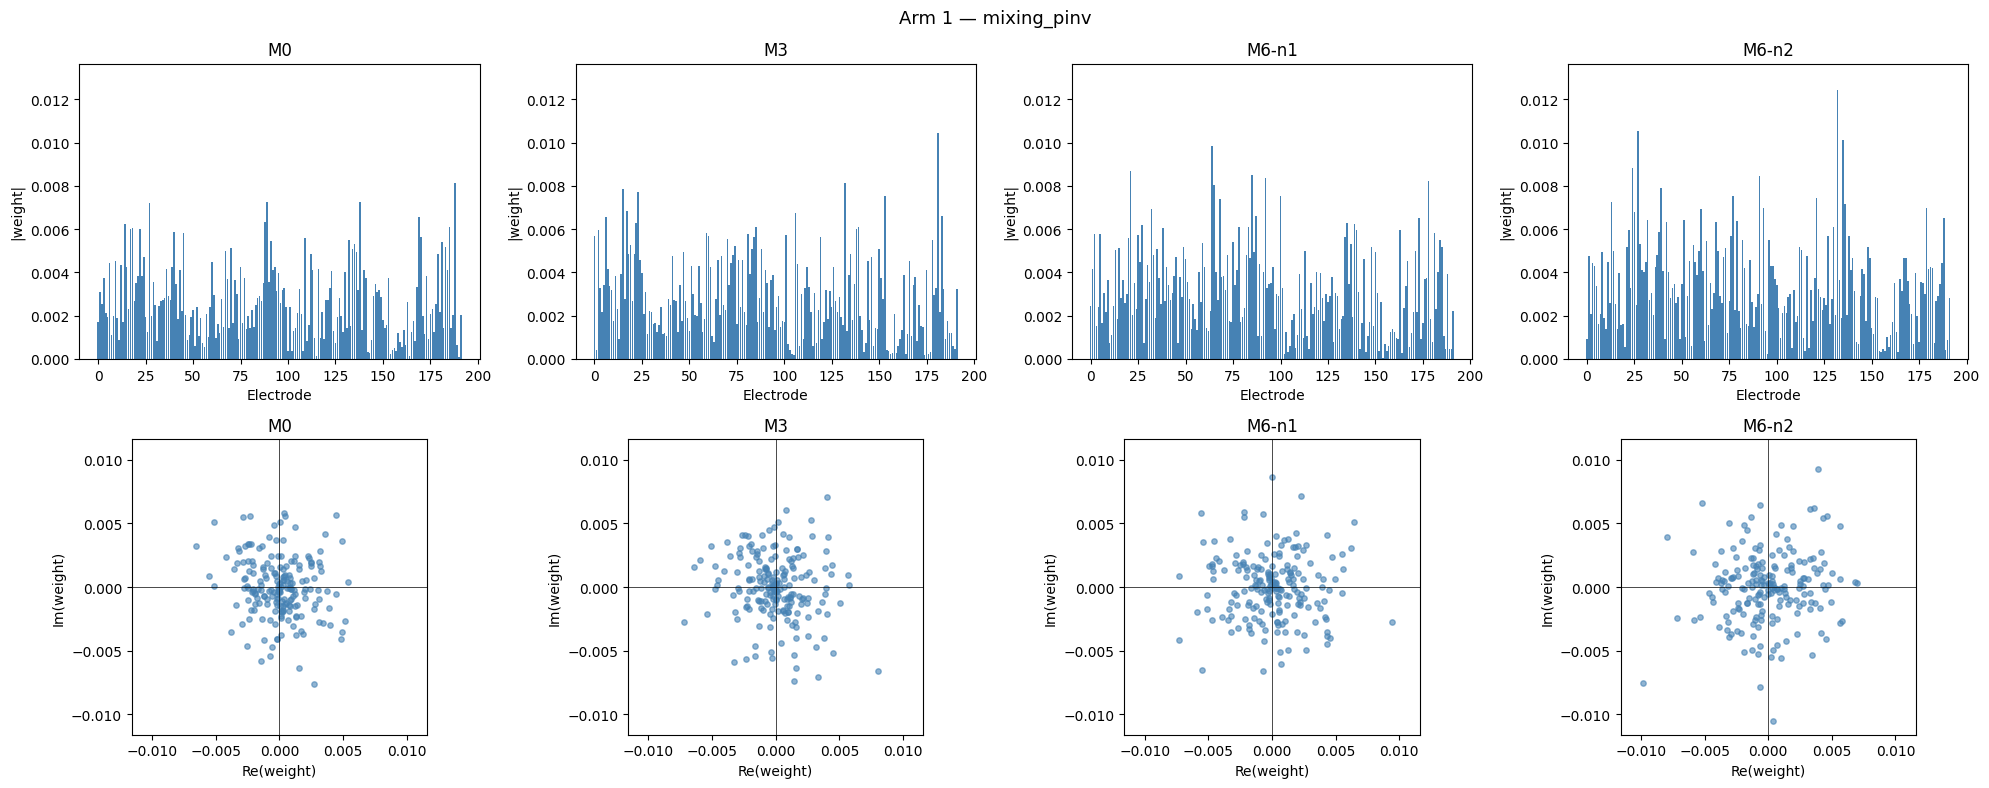

In [145]:
plot_arm_W(0,'mixing_pinv')

[(array([ -504057.66567651 +785836.23058051j,
        -344031.09718558 +972950.73347422j,
        -161153.9168783 +1335276.57907368j,
          -7088.19000393+1750407.17855361j,
         -85221.20647769+1445352.3724705j ,
          58662.25733995+2227198.64156225j,
        -241468.55301239+1152860.72106139j,
        -402040.00131636 +552816.07314059j,
         -71314.18991848+1590204.31368988j,
        -522678.2427494  +137047.72717426j,
        -728029.37587308 -689614.51243993j,
        -676285.00129302 -522194.60229014j,
          41732.72092276+1900419.71746582j,
        -431388.67189812 +304986.37606098j,
        -422483.76443456 +519129.26723436j,
        -319690.27668356 +986973.19460123j,
         320376.29897626+3132353.02191303j,
         259455.00216352+3240954.88322514j,
         302333.09146096+3240489.10503773j,
         492004.57025869+3334553.25735102j,
         680935.48348859+3293951.72068405j,
         752228.24282093+3257306.2131831j ,
         582512.51862035+32385

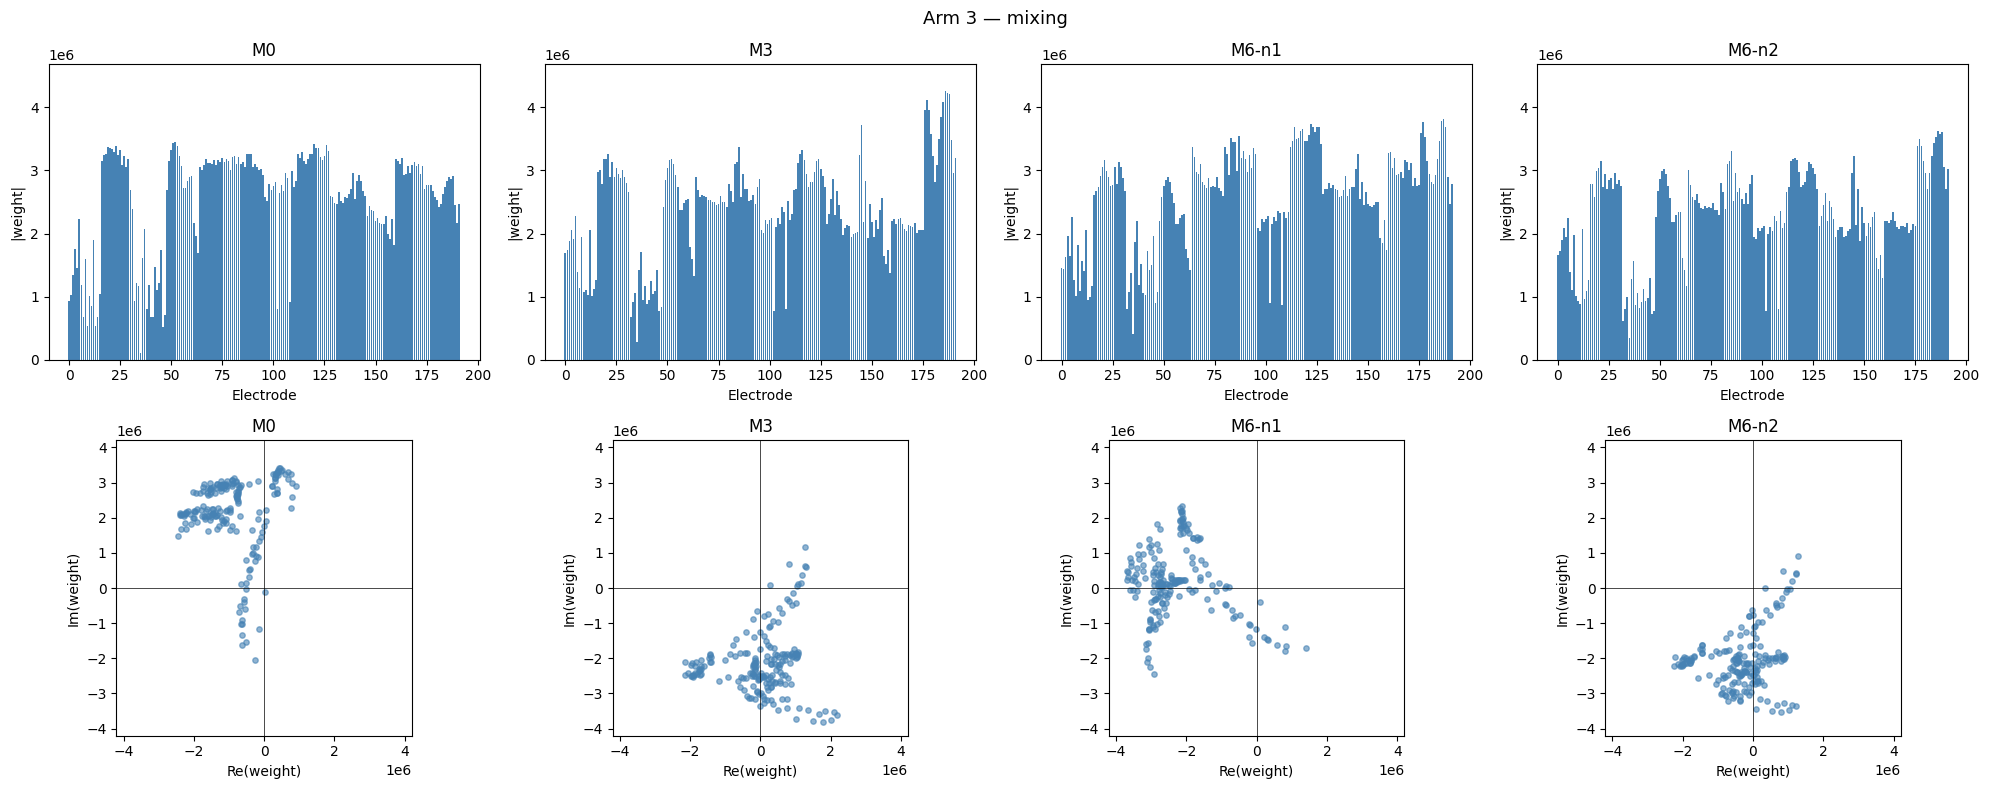

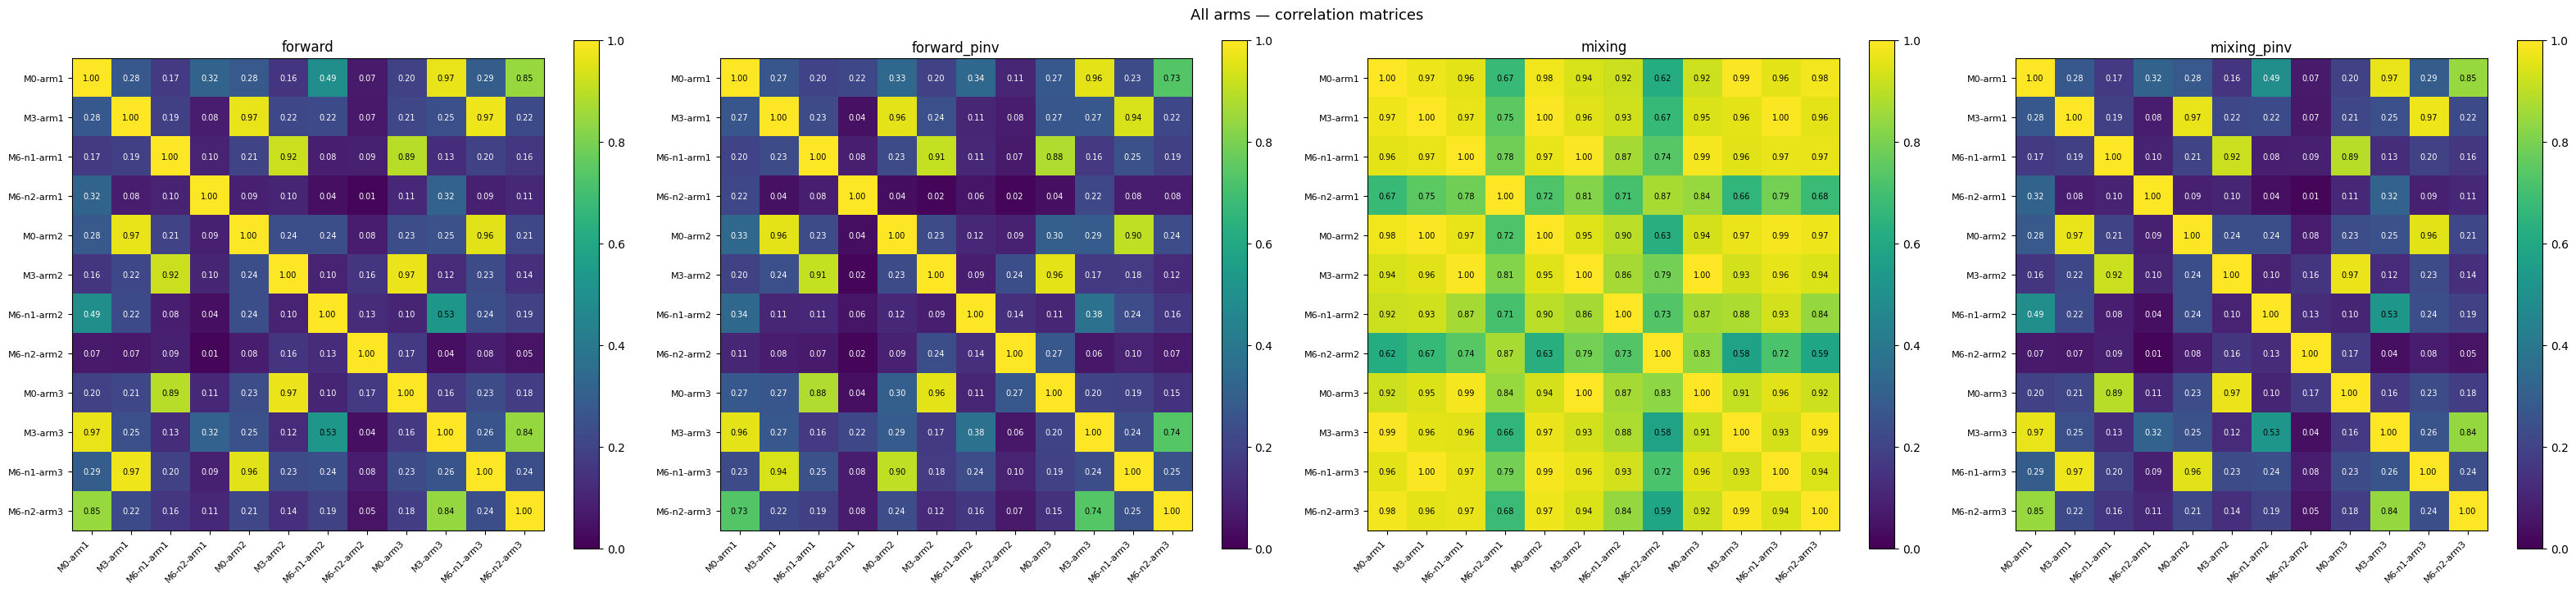

In [146]:

# ── usage examples ────────────────────────────────────────────────────────────

# single arm, one matrix type
plot_arm_W(arm_idx=2, matrix='mixing')

# single arm correlation matrix
#plot_corrmat(arm=0, matrix='mixing')

# all arms, all four matrix types side by side
plot_corrmat(arm='all', matrix=['forward', 'forward_pinv', 'mixing', 'mixing_pinv'])

#color code by electrode 

#relative phase calculation

#model how physics change with a vector feild in the electrode space
#does vector field is the same across 3 arms
#Model how plots change with arrows
# rotate all plots - force timbre weights using batch + L2 norm or unit_norm

# correlation matrix for 4 differnt matricies the X @ U^T/Xv @ T3 that is different somehow

#average a couple runs for consitancy

#non linear dynamical systems, graph the circle plot for time (as axis) for proof of concept before SINDY


#HSV color space

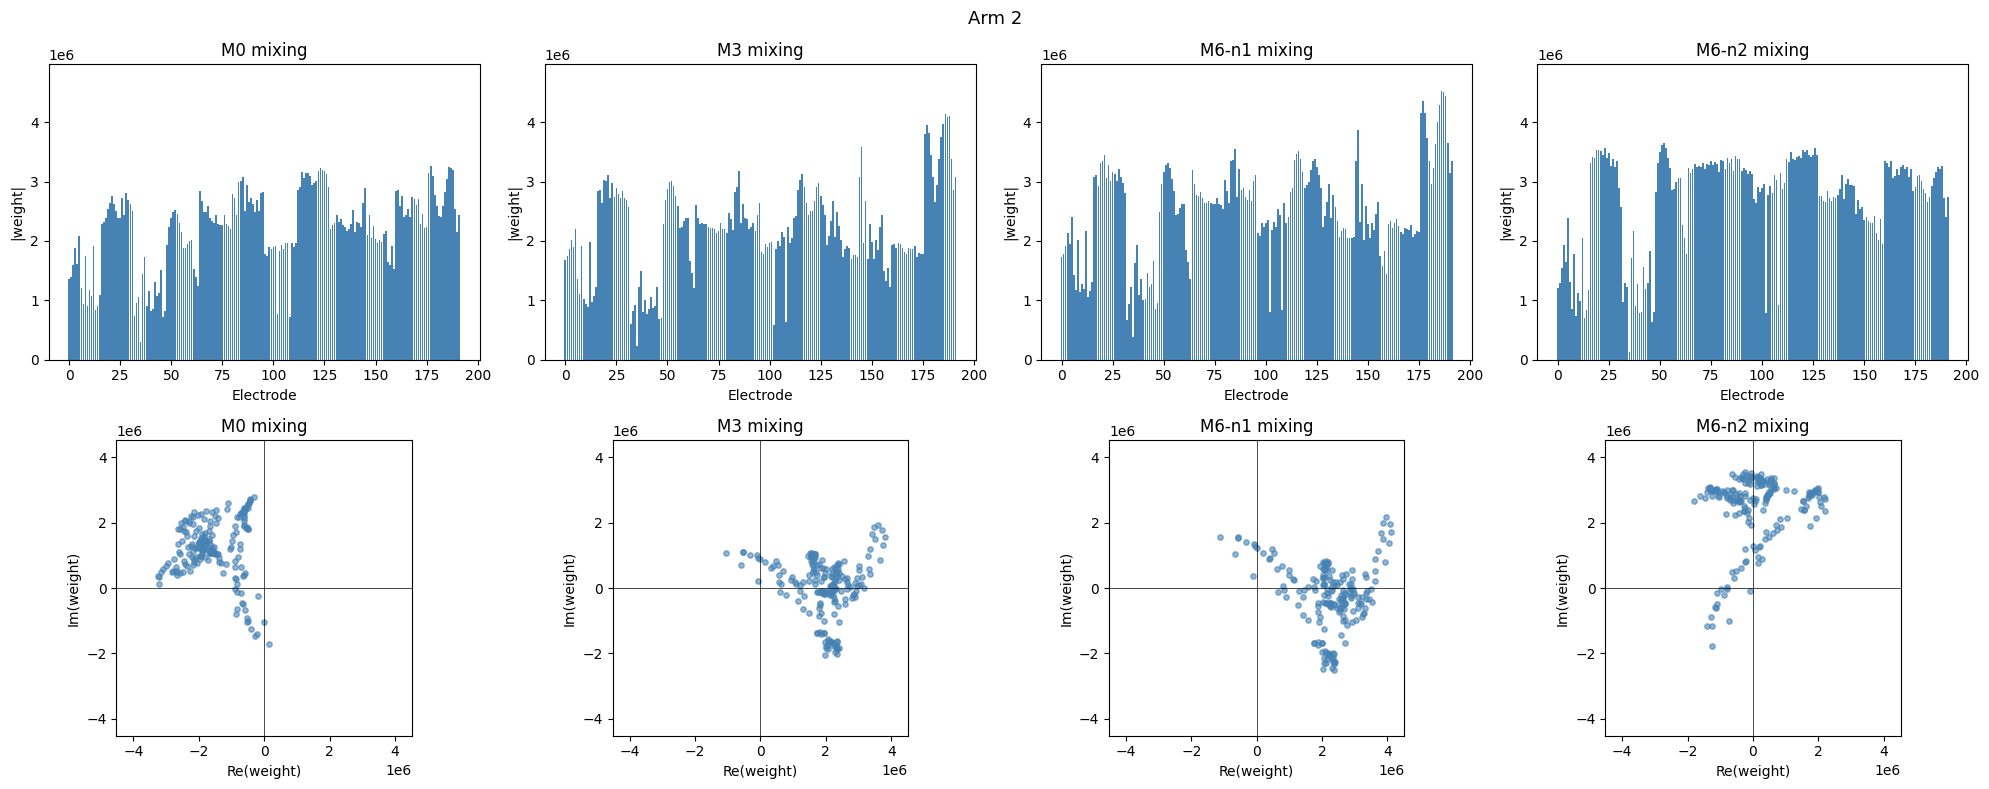

In [150]:
  def plot_arm_W_manual(arm_idx, filters):
      """
      arm_idx : int (0/1/2) — just used for the title
      filters : list of (label, f) tuples where f is a (192,) complex array

      Example:
          filters = [
              ('M0',      eSpace0[:, arm_nodes_m0[arm_idx][0]]),
              ('M3',      eSpace3[:, arm_nodes_m3[arm_idx][0]]),
              ('M6-n1',   eSpace6[:, arm_nodes_m6[arm_idx][0]]),
              ('M6-n2',   eSpace6[:, arm_nodes_m6[arm_idx][1]]),
          ]
      """
      n_cols = len(filters)
      fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8))
      fig.suptitle(f'Arm {arm_idx + 1}', fontsize=13)

      vmax_mag = max(np.max(np.abs(f)) for _, f in filters)
      vmax_ri  = max(max(np.max(np.abs(f.real)), np.max(np.abs(f.imag))) for _, f in filters)

      for col, (label, f) in enumerate(filters):
          # top row: magnitude bar chart
          axes[0, col].bar(range(len(f)), np.abs(f), color='steelblue', alpha=1.0)
          axes[0, col].set_ylim(0, vmax_mag * 1.1)
          axes[0, col].set_title(label)
          axes[0, col].set_xlabel('Electrode')
          axes[0, col].set_ylabel('|weight|')

          # bottom row: real vs imaginary scatter
          axes[1, col].scatter(f.real, f.imag, alpha=0.6, s=15, color='steelblue')
          axes[1, col].axhline(0, color='k', lw=0.5)
          axes[1, col].axvline(0, color='k', lw=0.5)
          axes[1, col].set_xlim(-vmax_ri * 1.1, vmax_ri * 1.1)
          axes[1, col].set_ylim(-vmax_ri * 1.1, vmax_ri * 1.1)
          axes[1, col].set_title(label)
          axes[1, col].set_xlabel('Re(weight)')
          axes[1, col].set_ylabel('Im(weight)')
          axes[1, col].set_aspect('equal')

      plt.tight_layout()
      plt.show()


  # --- Usage ---
  arm_idx = 1

#  plot_arm_W_manual(arm_idx, [
#      ('M0 forward',       eSpace0[:, arm_nodes_m0[arm_idx][0]]),
#      ('M3 forward',       eSpace3[:, arm_nodes_m3[arm_idx][0]]),
#      ('M6-n1 forward',    eSpace6[:, arm_nodes_m6[arm_idx][0]]),
#      ('M6-n2 forward',    eSpace6[:, arm_nodes_m6[arm_idx][1]]),
#  ])

  # swap to mixing matrices — just change the arrays:
  plot_arm_W_manual(arm_idx, [
      ('M0 mixing',        W0_mix[arm_nodes_m0[arm_idx][0], :]),
      ('M3 mixing',        W3_mix[arm_nodes_m3[arm_idx][0], :]),
      ('M6-n1 mixing',     W6_mix[arm_nodes_m6[arm_idx][0], :]),
      ('M6-n2 mixing',     W6_mix[arm_nodes_m6[arm_idx][1], :]),
  ])


In [ ]:
from primitives import sim, align

In [122]:
def stability_report(runs, arm_idx):
    """
    runs : list of dicts, one per training run, each:
        { 'W3_mix': (3,192) complex,
          'W6_mix': (6,192) complex,
          'arm_nodes_m3': arm->list of node idxs,
          'arm_nodes_m6': arm->list of node idxs }
    arm_idx : which arm to inspect.
 
    Prints the numbers that decide whether n1/n2 are individually meaningful.
    """
    # pull the three fields per run, for this arm
    m3, n1, n2 = [], [], []
    for r in runs:
        m3.append(r['W3_mix'][r['arm_nodes_m3'][arm_idx][0], :])
        n1.append(r['W6_mix'][r['arm_nodes_m6'][arm_idx][0], :])
        n2.append(r['W6_mix'][r['arm_nodes_m6'][arm_idx][1], :])
 
    def cross(label, vecs):
        vals = [sim(a, b) for a, b in combinations(vecs, 2)]
        vals = np.array(vals)
        print(f"  {label}: mean={vals.mean():.3f}  min={vals.min():.3f}  "
              f"n_pairs={len(vals)}")
        return vals
 
    print(f"=== Arm {arm_idx} :: cross-run self-similarity (is the node stable?) ===")
    s_n1 = cross("sim(n1_A, n1_B)", n1)
    s_n2 = cross("sim(n2_A, n2_B)", n2)
    s_m3 = cross("sim(m3_A, m3_B)", m3)
 
    print(f"\n=== Arm {arm_idx} :: does n1 track M3? does n2 avoid it? ===")
    n1_m3 = np.array([sim(n1[i], m3[i]) for i in range(len(runs))])
    n2_m3 = np.array([sim(n2[i], m3[i]) for i in range(len(runs))])
    print(f"  sim(n1, m3) per run: mean={n1_m3.mean():.3f}  "
          f"vals={np.round(n1_m3,2)}")
    print(f"  sim(n2, m3) per run: mean={n2_m3.mean():.3f}  "
          f"vals={np.round(n2_m3,2)}")
 
    print(f"\n=== INTERPRETATION ===")
    print("  n1 self-sim high AND n2 self-sim high  -> both stable; n1/n2 split is real")
    print("  n1 self-sim high BUT n2 self-sim LOWER  -> plane is stable, n2 axis wanders")
    print("     (=> don't study n2 alone; use the n1/n2 SUBSPACE)")
    print("  n1->m3 high AND n2->m3 low              -> confirms 'n1 relearns M3'")
 
    return dict(n1_self=s_n1, n2_self=s_n2, m3_self=s_m3,
                n1_m3=n1_m3, n2_m3=n2_m3)
 

In [ ]:
from itertools import combinations

runs = []
N_RUNS = 5

for _ in range(N_RUNS):
    m3, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)
    m6, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

    raw3 = helpers.layer_output(wLFPs, m3, 0)
    acts3 = raw3[:, :3] + 1j * raw3[:, 3:]
    W3_mix = np.linalg.pinv(acts3[train_inds]) @ LFPs[train_inds]

    raw6 = helpers.layer_output(wLFPs, m6, 0)
    acts6 = raw6[:, :6] + 1j * raw6[:, 6:]
    W6_mix = np.linalg.pinv(acts6[train_inds]) @ LFPs[train_inds]

    runs.append({
        'W3_mix': W3_mix,
        'W6_mix': W6_mix,
        'arm_nodes_m3': helpers.node_arm_map(m3, wLFPs, test_inds, data['lapID'], top_k=1),
        'arm_nodes_m6': helpers.node_arm_map(m6, wLFPs, test_inds, data['lapID'], top_k=2),
    })

rep = stability_report(runs, arm_idx=0)

In [42]:
#W0_mix = np.conj(acts0[train_inds]).T @ LFPs[train_inds]  # (3,  192)
#W3_mix = np.conj(acts3[train_inds]).T @ LFPs[train_inds]  # (3,  192)
#W6_mix = np.conj(acts6[train_inds]).T @ LFPs[train_inds]  # (6,  192)

W6_mix[arm_nodes_m6[arm_idx][0], :].shape, W6_mix[arm_nodes_m6[arm_idx][1], :].shape, W3_mix[arm_nodes_m3[arm_idx][0], :].shape

((192,), (192,), (192,))

In [ ]:
from primitives import orthobasis, principal_cos


def subspace_sim(vecsA, vecsB):
    """
    Plane-to-plane similarity, basis-invariant.
    vecsA, vecsB : lists of vectors spanning each subspace (e.g. [n1, n2]).
    Returns (mean_cos, min_cos, cos_per_angle).
      mean_cos -> overall alignment;  min_cos -> worst-aligned direction.
    """
    QA = orthobasis(vecsA)
    QB = orthobasis(vecsB)
    cos = principal_cos(QA, QB)
    return cos.mean(), cos.min(), cos
 
 
def plane_stability_report(runs, arm_idx):
    """
    runs : list of run-dicts, each with 'W6_mix' (6,192) and
           'arm_nodes_m6' (arm -> list of >=2 node idxs).
    For every pair of runs, computes principal-angle cosines between the
    two {n1,n2} planes for this arm. Compares against the individual-node
    sims so you can see the 'plane stable / axis wanders' gap directly.
    """
    # individual-vector sim, for the contrast (rotation-invariant)
    def vsim(a, b):
        return np.abs(np.sum(np.conj(a) * b)) / (np.linalg.norm(a) * np.linalg.norm(b))
 
    planes, n1s, n2s = [], [], []
    for r in runs:
        nodes = r['arm_nodes_m6'][arm_idx]
        v1 = r['W6_mix'][nodes[0], :]
        v2 = r['W6_mix'][nodes[1], :]
        planes.append([v1, v2])
        n1s.append(v1)
        n2s.append(v2)
 
    print(f"=== Arm {arm_idx} :: PLANE stability (principal angles) ===")
    mean_cos, min_cos, all_cos = [], [], []
    for (i, pA), (j, pB) in combinations(enumerate(planes), 2):
        mc, mn, cos = subspace_sim(pA, pB)
        mean_cos.append(mc); min_cos.append(mn); all_cos.append(cos)
    mean_cos = np.array(mean_cos); min_cos = np.array(min_cos)
    all_cos = np.array(all_cos)                      # (n_pairs, k)
 
    print(f"  mean cos(principal angles): mean={mean_cos.mean():.3f}  "
          f"min={mean_cos.min():.3f}")
    print(f"  worst principal angle cos : mean={min_cos.mean():.3f}  "
          f"min={min_cos.min():.3f}   (this is the tilted direction)")
    print(f"  per-angle cos (avg over pairs): {np.round(all_cos.mean(axis=0),3)}")
 
    print(f"\n=== contrast: individual-node sims (from the gate) ===")
    n1_pairs = np.array([vsim(a, b) for a, b in combinations(n1s, 2)])
    n2_pairs = np.array([vsim(a, b) for a, b in combinations(n2s, 2)])
    print(f"  sim(n1_A, n1_B): mean={n1_pairs.mean():.3f}")
    print(f"  sim(n2_A, n2_B): mean={n2_pairs.mean():.3f}   <- the wandering axis")
 
    print(f"\n=== READ ===")
    print("  plane mean_cos HIGH while n2 sim LOW")
    print("     -> plane is stable, n2 axis wanders within it.")
    print("        Study the SUBSPACE (and the M3-orthogonal direction), not n2.")
    print("  plane mean_cos ALSO low")
    print("     -> even the plane wanders: M6 isn't finding a consistent 2D")
    print("        solution. 'Averaging the extra node' is then not meaningful.")
 
    return dict(plane_mean_cos=mean_cos, plane_min_cos=min_cos,
                per_angle_cos=all_cos, n1_sim=n1_pairs, n2_sim=n2_pairs)

In [134]:
plane_stability_report(runs,2)

=== Arm 2 :: PLANE stability (principal angles) ===
  mean cos(principal angles): mean=0.813  min=0.653
  worst principal angle cos : mean=0.627  min=0.308   (this is the tilted direction)
  per-angle cos (avg over pairs): [0.999 0.627]

=== contrast: individual-node sims (from the gate) ===
  sim(n1_A, n1_B): mean=0.992
  sim(n2_A, n2_B): mean=0.789   <- the wandering axis

=== READ ===
  plane mean_cos HIGH while n2 sim LOW
     -> plane is stable, n2 axis wanders within it.
        Study the SUBSPACE (and the M3-orthogonal direction), not n2.
  plane mean_cos ALSO low
     -> even the plane wanders: M6 isn't finding a consistent 2D
        solution. 'Averaging the extra node' is then not meaningful.


{'plane_mean_cos': array([0.97529452, 0.73737755, 0.98136873, 0.76342532, 0.72189331,
        0.95817027, 0.65269633, 0.76711877, 0.80224767, 0.76771791]),
 'plane_min_cos': array([0.95294963, 0.47557338, 0.96316666, 0.52709492, 0.44590277,
        0.91809092, 0.3076336 , 0.53476448, 0.6046414 , 0.53581645]),
 'per_angle_cos': array([[0.99763941, 0.95294963],
        [0.99918173, 0.47557338],
        [0.99957079, 0.96316666],
        [0.99975572, 0.52709492],
        [0.99788385, 0.44590277],
        [0.99824963, 0.91809092],
        [0.99775905, 0.3076336 ],
        [0.99947306, 0.53476448],
        [0.99985394, 0.6046414 ],
        [0.99961937, 0.53581645]]),
 'n1_sim': array([0.9947148 , 0.99144897, 0.99397597, 0.99161458, 0.98541022,
        0.990872  , 0.9832273 , 0.99508569, 0.99873862, 0.9962768 ]),
 'n2_sim': array([0.94662395, 0.75025124, 0.9103651 , 0.90655592, 0.61674821,
        0.79084749, 0.80686309, 0.74534792, 0.61618752, 0.8000153 ])}

In [ ]:
from primitives import extra_subspace, participation_ratio, principal_cos


def pooled_dimensionality(runs, arm_idx):
    """
    Stack every run's extra-subspace basis columns into one matrix and ask how
    many dimensions they collectively span (participation ratio + spectrum).
    """
    cols = []
    for r in runs:
        arm_nodes = r['arm_nodes'][arm_idx]
        vecs = [r['W_mix'][n, :] for n in arm_nodes]
        m3 = r['W3_mix'][r['arm_nodes_m3'][arm_idx][0], :]
        Qx = extra_subspace(vecs, m3)            # (192, k-1)
        for c in range(Qx.shape[1]):
            cols.append(Qx[:, c])
    big = np.column_stack(cols)                  # (192, N*(k-1))
    sv = np.linalg.svd(big, compute_uv=False)
    return participation_ratio(sv), sv
 
 
def subspace_stability(runs, arm_idx):
    """mean cos of principal angles between extra subspaces, over run-pairs."""
    extras = []
    for r in runs:
        arm_nodes = r['arm_nodes'][arm_idx]
        vecs = [r['W_mix'][n, :] for n in arm_nodes]
        m3 = r['W3_mix'][r['arm_nodes_m3'][arm_idx][0], :]
        extras.append(extra_subspace(vecs, m3))
    means = []
    for (i, A), (j, B) in combinations(enumerate(extras), 2):
        k = min(A.shape[1], B.shape[1])
        cos = principal_cos(A[:, :k], B[:, :k])
        means.append(cos.mean())
    return np.mean(means), np.array(means)
 
 
# ---- the sweep -------------------------------------------------------------
def node_count_sweep(runs_by_count, arm_idx=0):
    """
    runs_by_count : dict {node_count: [run_dict, ...]}, each run_dict:
        { 'W_mix': (n_nodes,192), 'arm_nodes': arm->list,
          'W3_mix': (3,192), 'arm_nodes_m3': arm->list }
    """
    print(f"=== Node-count sweep, arm {arm_idx} ===\n")
    print(f"{'nodes':>6} {'extra/arm':>10} {'pooled_eff_dim':>15} "
          f"{'subspace_stab':>14}")
    results = {}
    for nc in sorted(runs_by_count):
        runs = runs_by_count[nc]
        n_extra = len(runs[0]['arm_nodes'][arm_idx]) - 1   # k-1
        eff_dim, spectrum = pooled_dimensionality(runs, arm_idx)
        stab, _ = subspace_stability(runs, arm_idx)
        results[nc] = dict(n_extra=n_extra, eff_dim=eff_dim,
                           spectrum=spectrum, stability=stab)
        print(f"{nc:>6} {n_extra:>10} {eff_dim:>15.2f} {stab:>14.3f}")
 
    print("\n=== READ ===")
    print("  pooled_eff_dim GROWS past 1 as you add runs/nodes,")
    print("    and subspace_stab RISES toward 1 as nodes catch up to that dim")
    print("    -> UNDER-PROVISIONING (A): extra space is multi-D; M6 undersampled it.")
    print("  pooled_eff_dim stays ~1 at every node count,")
    print("    and stability never locks -> NOISE (B): 1D, noisily estimated.")
    print("\n  the decisive number is pooled_eff_dim AT M6:")
    print("    >1 means the wandering directions span multiple dims => (A).")
    return results

In [ ]:
def make_runs(n_nodes, n_runs=5):
    runs = []
    top_k = n_nodes // 3                       # nodes per arm: 2,4,8 for 6,12,24
    for _ in range(n_runs):
        m3, _, _ = TIMBRE(wLFPs, data['lapID'][:,1], test_inds, train_inds, hidden_nodes=3)
        mk, _, _ = TIMBRE(wLFPs, data['lapID'][:,1], test_inds, train_inds, hidden_nodes=n_nodes)
        raw3 = helpers.layer_output(wLFPs, m3, 0)
        acts3 = raw3[:, :3] + 1j*raw3[:, 3:]
        W3 = np.linalg.pinv(acts3[train_inds]) @ LFPs[train_inds]
        rawk = helpers.layer_output(wLFPs, mk, 0)
        actsk = rawk[:, :n_nodes] + 1j*rawk[:, n_nodes:]
        Wk = np.linalg.pinv(actsk[train_inds]) @ LFPs[train_inds]
        runs.append({
            'W_mix': Wk,
            'arm_nodes': helpers.node_arm_map(mk, wLFPs, test_inds, data['lapID'], top_k=top_k),
            'W3_mix': W3,
            'arm_nodes_m3': helpers.node_arm_map(m3, wLFPs, test_inds, data['lapID'], top_k=1),
        })
    return runs

runs_by_count = {6: make_runs(6), 12: make_runs(12), 24: make_runs(24)}
res = node_count_sweep(runs_by_count, arm_idx=0)

In [ ]:
from primitives import orthobasis, principal_cos

In [142]:
res[6]['eff_dim']

np.float64(2.7226107274378144)

In [ ]:
from analysis import test_accuracy, capstone_figure
from primitives import partition_ok

In [ ]:
eff_dims = {6: 2.72, 12: 4.78, 24: 10.38}
for nc in (48, 96, 120):
    runs = make_runs(nc)
    if not partition_ok(runs[0]['arm_nodes'], nc):
        print(f"WARNING n_nodes={nc}: arm overlap -> eff_dim may be inflated")
    ed, _ = pooled_dimensionality(runs, arm_idx=0)
    eff_dims[nc] = ed

# 2) test accuracy — REPLACE with your actual numbers off the orange curve
test_accs  = {3: 0.664, 6: 0.705, 12: 0.720, 24: 0.745, 48: 0.756, 96: 0.76, 120: 0.765}
train_accs = {3: 0.733, 6: 0.788, 12: 0.88, 24: 0.916, 48: 0.924, 96: 0.96, 120: 0.964}

# 3) the figure
fig = capstone_figure(eff_dims, test_accs, train_accs, title="Stay")
plt.show()